# LSTM Gizli Birim Sayısı Deneyi

Bu notebook, LSTM modeli için 16 ve 32 gizli birimi validation döneminde karşılaştırır. Yalnızca hidden size değiştirilir; veri bölünmesi, 20 günlük lookback, katman sayısı, optimizer, epoch bütçesi ve seed sabit tutulur. Test dönemi kullanılmaz.

In [1]:
import copy
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from torch import nn
from torch.optim import Adam

from ms_stock_prediction.models import LSTMModel, count_trainable_parameters
from ms_stock_prediction.preprocessing import (
    PreparationConfig,
    load_close_prices,
    prepare_time_series,
)
from ms_stock_prediction.training import evaluate_loss, train_one_epoch

SEED = 42
HIDDEN_SIZES = (16, 32)
EPOCHS = 100
LEARNING_RATE = 0.001
LOOKBACK = 20
NUM_LAYERS = 2
BATCH_SIZE = 32
DEVICE = torch.device("cpu")

pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
plt.style.use("seaborn-v0_8-whitegrid")

## Kontrollü deney düzeni

Her hidden size değeri için DataLoader ve model aynı seed ile yeniden oluşturulur. Modeller 100 epoch eğitilir ve en düşük validation kaybındaki ağırlıklar değerlendirilir. Giriş ve hedef tensorları aynı olduğu için model kapasitesinin etkisi doğrudan karşılaştırılır.

In [2]:
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if not (PROJECT_ROOT / "pyproject.toml").exists():
    raise FileNotFoundError("Proje kökü bulunamadı. Notebook'u proje içinde çalıştırın.")

DATA_PATH = PROJECT_ROOT / "data/raw/msft_daily_latest.csv"
prices = load_close_prices(DATA_PATH)
config = PreparationConfig(
    lookback=LOOKBACK,
    batch_size=BATCH_SIZE,
    shuffle_seed=SEED,
)

print(f"Kapanış fiyatı gözlemi: {len(prices):,}")
print(f"Tarih aralığı: {prices.index.min().date()} - {prices.index.max().date()}")

Kapanış fiyatı gözlemi: 4,156
Tarih aralığı: 2010-01-04 - 2026-07-14


In [3]:
def regression_metrics(actual, predicted):
    errors = predicted - actual
    mse = float(np.mean(errors**2))
    return {
        "MSE (USD²)": mse,
        "RMSE (USD)": float(np.sqrt(mse)),
        "MAE (USD)": float(np.mean(np.abs(errors))),
    }


def run_hidden_size_experiment(hidden_size):
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)

    prepared = prepare_time_series(prices, config)
    model = LSTMModel(
        input_size=1,
        hidden_size=hidden_size,
        num_layers=NUM_LAYERS,
        output_size=1,
    ).to(DEVICE)
    loss_function = nn.MSELoss()
    optimizer = Adam(model.parameters(), lr=LEARNING_RATE)

    history = []
    best_validation_loss = float("inf")
    best_epoch = 0
    best_model_state = None
    training_started = time.perf_counter()

    for epoch in range(1, EPOCHS + 1):
        train_loss = train_one_epoch(
            model, prepared.train_loader, optimizer, loss_function, DEVICE
        )
        validation_loss = evaluate_loss(
            model, prepared.validation_loader, loss_function, DEVICE
        )
        history.append(
            {
                "Epoch": epoch,
                "Train MSE (scaled)": train_loss,
                "Validation MSE (scaled)": validation_loss,
            }
        )

        if validation_loss < best_validation_loss:
            best_validation_loss = validation_loss
            best_epoch = epoch
            best_model_state = copy.deepcopy(model.state_dict())

        if epoch == 1 or epoch % 10 == 0:
            print(
                f"Hidden {hidden_size:02d} | epoch {epoch:03d}/{EPOCHS} | "
                f"train={train_loss:.6f} | validation={validation_loss:.6f}"
            )

    training_seconds = time.perf_counter() - training_started
    if best_model_state is None:
        raise RuntimeError("Eğitim sırasında geçerli model ağırlığı üretilemedi.")

    model.load_state_dict(best_model_state)
    model.eval()
    with torch.no_grad():
        predicted_scaled = model(prepared.X_validation.to(DEVICE)).cpu().numpy()

    actual_scaled = prepared.y_validation.numpy()
    predicted_usd = prepared.scaler.inverse_transform(predicted_scaled).ravel()
    actual_usd = prepared.scaler.inverse_transform(actual_scaled).ravel()
    metrics = regression_metrics(actual_usd, predicted_usd)

    outcome = {
        "Hidden size": hidden_size,
        "Seçilen epoch": best_epoch,
        **metrics,
        "Parametre": count_trainable_parameters(model),
        "Eğitim süresi (sn)": training_seconds,
    }

    return (
        prepared,
        pd.DataFrame(history).set_index("Epoch"),
        outcome,
        predicted_usd,
        actual_usd,
    )

## Eğitim çalışmaları

İki LSTM modeli birbirinden bağımsız ve aynı başlangıç koşullarıyla eğitilir.

In [4]:
experiment_artifacts = {}
outcomes = []

for hidden_size in HIDDEN_SIZES:
    prepared, history, outcome, prediction, actual = run_hidden_size_experiment(
        hidden_size
    )
    experiment_artifacts[hidden_size] = {
        "prepared": prepared,
        "history": history,
        "prediction": prediction,
        "actual": actual,
    }
    outcomes.append(outcome)

reference_prepared = experiment_artifacts[HIDDEN_SIZES[0]]["prepared"]
reference_dates = reference_prepared.validation_target_dates
reference_actual = experiment_artifacts[HIDDEN_SIZES[0]]["actual"]
for hidden_size in HIDDEN_SIZES[1:]:
    candidate_prepared = experiment_artifacts[hidden_size]["prepared"]
    assert reference_dates.equals(candidate_prepared.validation_target_dates)
    assert torch.equal(reference_prepared.X_train, candidate_prepared.X_train)
    assert np.array_equal(reference_actual, experiment_artifacts[hidden_size]["actual"])

Hidden 16 | epoch 001/100 | train=0.247999 | validation=1.577547


Hidden 16 | epoch 010/100 | train=0.000604 | validation=0.070650


Hidden 16 | epoch 020/100 | train=0.000494 | validation=0.028937


Hidden 16 | epoch 030/100 | train=0.000401 | validation=0.013714


Hidden 16 | epoch 040/100 | train=0.000358 | validation=0.007618


...

Hidden 32 | epoch 060/100 | train=0.000220 | validation=0.002237


Hidden 32 | epoch 070/100 | train=0.000212 | validation=0.002137


Hidden 32 | epoch 080/100 | train=0.000213 | validation=0.002292


Hidden 32 | epoch 090/100 | train=0.000211 | validation=0.001939


Hidden 32 | epoch 100/100 | train=0.000200 | validation=0.002186


In [5]:
results = pd.DataFrame(outcomes).sort_values("Hidden size").reset_index(drop=True)
display(results)

naive_scaled = reference_prepared.X_validation[:, -1, 0].numpy().reshape(-1, 1)
naive_usd = reference_prepared.scaler.inverse_transform(naive_scaled).ravel()
naive_metrics = regression_metrics(reference_actual, naive_usd)

print(
    f"Naive baseline | RMSE={naive_metrics['RMSE (USD)']:.4f} USD | "
    f"MAE={naive_metrics['MAE (USD)']:.4f} USD"
)

,Hidden size,Seçilen epoch,MSE (USD²),RMSE (USD),MAE (USD),Parametre,Eğitim süresi (sn)
0,16,96,51.7982,7.1971,5.5992,3409,31.9028
1,32,96,29.4468,5.4265,4.2340,12961,36.7050


Naive baseline | RMSE=4.9875 USD | MAE=3.7967 USD


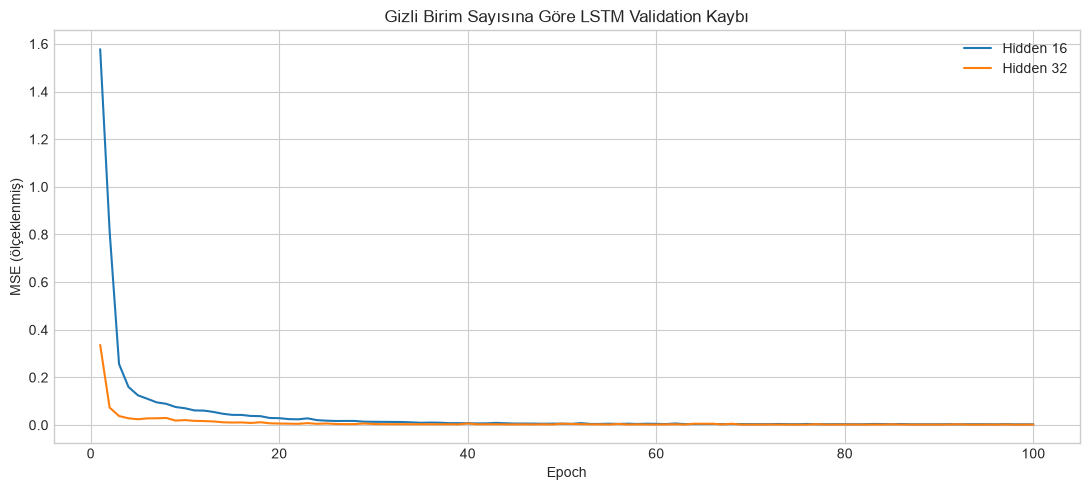

In [6]:
fig, ax = plt.subplots(figsize=(11, 5))
for hidden_size in HIDDEN_SIZES:
    history = experiment_artifacts[hidden_size]["history"]
    history["Validation MSE (scaled)"].plot(
        ax=ax, label=f"Hidden {hidden_size}", linewidth=1.5
    )
ax.set_title("Gizli Birim Sayısına Göre LSTM Validation Kaybı")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE (ölçeklenmiş)")
ax.legend()
plt.tight_layout()
plt.show()

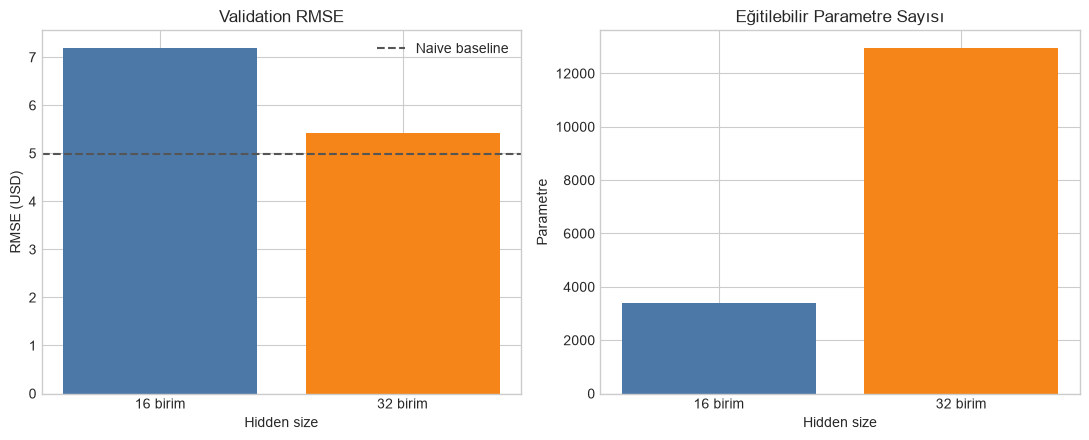

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
labels = results["Hidden size"].map(lambda value: f"{value} birim")

axes[0].bar(labels, results["RMSE (USD)"], color=["#4C78A8", "#F58518"])
axes[0].axhline(
    naive_metrics["RMSE (USD)"],
    color="#555555",
    linestyle="--",
    label="Naive baseline",
)
axes[0].set_title("Validation RMSE")
axes[0].set_xlabel("Hidden size")
axes[0].set_ylabel("RMSE (USD)")
axes[0].legend()

axes[1].bar(labels, results["Parametre"], color=["#4C78A8", "#F58518"])
axes[1].set_title("Eğitilebilir Parametre Sayısı")
axes[1].set_xlabel("Hidden size")
axes[1].set_ylabel("Parametre")

plt.tight_layout()
plt.show()

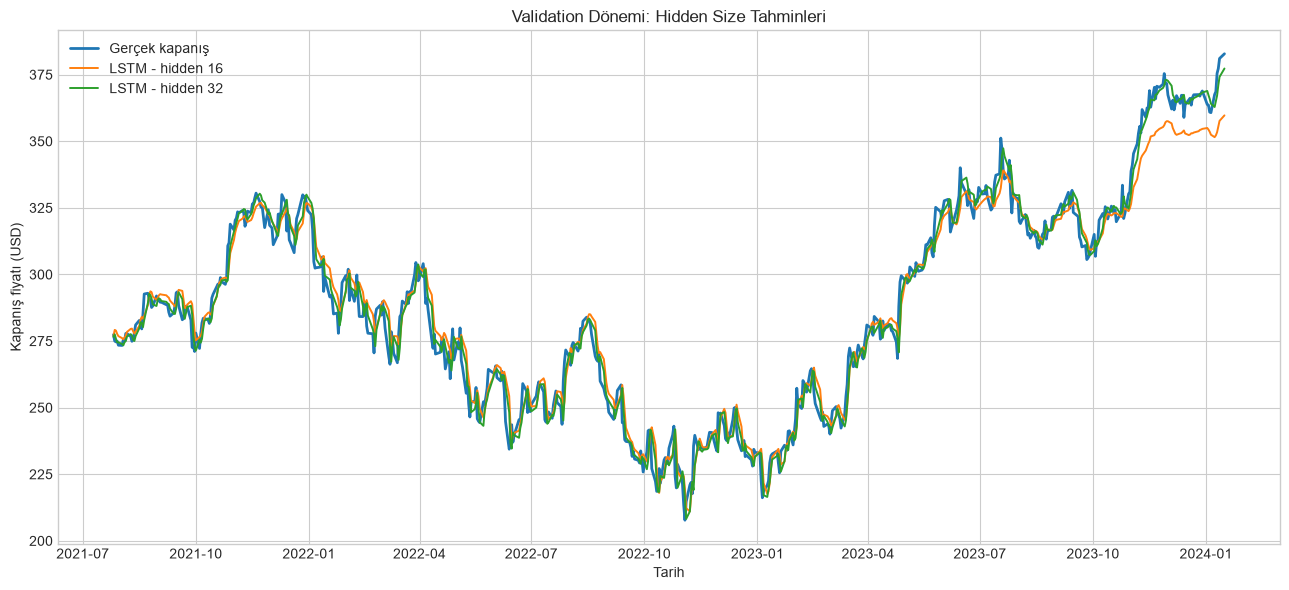

In [8]:
fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(reference_dates, reference_actual, label="Gerçek kapanış", linewidth=2)
for hidden_size in HIDDEN_SIZES:
    ax.plot(
        reference_dates,
        experiment_artifacts[hidden_size]["prediction"],
        label=f"LSTM - hidden {hidden_size}",
        linewidth=1.4,
    )
ax.set_title("Validation Dönemi: Hidden Size Tahminleri")
ax.set_xlabel("Tarih")
ax.set_ylabel("Kapanış fiyatı (USD)")
ax.legend()
plt.tight_layout()
plt.show()

## Validation bulguları

Aşağıdaki özet, model kapasitesinin validation performansına etkisini gösterir. Sonuçlar test performansı değildir.

In [9]:
best_index = results["RMSE (USD)"].idxmin()
best_row = results.loc[best_index]
rmse_16 = results.loc[results["Hidden size"] == 16, "RMSE (USD)"].iloc[0]
rmse_32 = results.loc[results["Hidden size"] == 32, "RMSE (USD)"].iloc[0]
parameter_16 = results.loc[results["Hidden size"] == 16, "Parametre"].iloc[0]
parameter_32 = results.loc[results["Hidden size"] == 32, "Parametre"].iloc[0]
parameter_reduction = (1 - parameter_16 / parameter_32) * 100

assert np.isfinite(results[["RMSE (USD)", "MAE (USD)"]].to_numpy()).all()
assert reference_dates.max() < reference_prepared.test_target_dates.min()

print(f"16 gizli birim RMSE: {rmse_16:.4f} USD")
print(f"32 gizli birim RMSE: {rmse_32:.4f} USD")
print(f"RMSE farkı (16 - 32): {rmse_16 - rmse_32:+.4f} USD")
print(f"16 birimli modelin parametre azalması: %{parameter_reduction:.2f}")
print(
    f"En düşük LSTM validation RMSE: {int(best_row['Hidden size'])} birim / "
    f"{best_row['RMSE (USD)']:.4f} USD"
)
print(f"Naive baseline validation RMSE: {naive_metrics['RMSE (USD)']:.4f} USD")
print("Test dönemine ait tahmin veya metrik hesaplanmadı.")

16 gizli birim RMSE: 7.1971 USD
32 gizli birim RMSE: 5.4265 USD
RMSE farkı (16 - 32): +1.7706 USD
16 birimli modelin parametre azalması: %73.70
En düşük LSTM validation RMSE: 32 birim / 5.4265 USD
Naive baseline validation RMSE: 4.9875 USD
Test dönemine ait tahmin veya metrik hesaplanmadı.
